# Unit 2 code companion: A Map of Models

Fit every family on the menu to the same problem, see what each one hands back, and then compare two of them honestly.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv").dropna()
PREDS = ["weight", "displacement", "horsepower", "acceleration", "model_year", "cylinder"]
X, y = cars[PREDS], cars["mpg"]
print(cars.shape, bikes.shape)

(392, 9) (365, 8)


## 1. Two kinds of model on the same data

One names a distribution for mpg. The other just predicts it.

In [2]:
lin = smf.ols("mpg ~ weight + horsepower + model_year", data=cars).fit()
forest = RandomForestRegressor(n_estimators=400, random_state=0).fit(X, y)
print("linear, in-sample R^2:", round(lin.rsquared, 3))
print("forest, in-sample R^2:", round(forest.score(X, y), 3))

linear, in-sample R^2: 0.808
forest, in-sample R^2: 0.983


## 2. What each one hands back



In [3]:
print(lin.summary().tables[1])
print("\nAIC:", round(lin.aic, 1))
print("95% CI for weight:", lin.conf_int().loc["weight"].round(5).to_dict())

print("\n--- the forest ---")
imp = pd.Series(forest.feature_importances_, index=PREDS).sort_values(ascending=False)
print(imp.round(3).to_string())
for attr in ["pvalues", "conf_int", "aic", "bse"]:
    print(f"forest.{attr}:", "yes" if hasattr(forest, attr) else "does not exist")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -13.7194      4.182     -3.281      0.001     -21.941      -5.498
weight        -0.0064      0.000    -15.768      0.000      -0.007      -0.006
horsepower    -0.0050      0.009     -0.530      0.597      -0.024       0.014
model_year     0.7487      0.052     14.365      0.000       0.646       0.851

AIC: 2082.8
95% CI for weight: {0: -0.00725, 1: -0.00564}

--- the forest ---
displacement    0.332
weight          0.206
cylinder        0.193
model_year      0.122
horsepower      0.116
acceleration    0.031
forest.pvalues: does not exist
forest.conf_int: does not exist
forest.aic: does not exist
forest.bse: does not exist


Importances, and nothing else. No likelihood means no standard error, no $p$-value and no AIC. Those are undefined here, not hidden.

## 3. The type of y picks the probability model

Linear for a number, logistic for a yes/no, Poisson for a count. These are not interchangeable.

In [4]:
# a number
m_num = smf.ols("mpg ~ weight", data=cars).fit()

# a yes/no
cars["efficient"] = (cars["mpg"] > 30).astype(int)
m_bin = smf.logit("efficient ~ weight", data=cars).fit(disp=0)

# a count
m_cnt = smf.glm("Count ~ Temperature", data=bikes,
                family=sm.families.Poisson()).fit()

print(f"linear   slope on weight : {m_num.params['weight']:.5f} mpg per pound")
print(f"logistic slope on weight : {m_bin.params['weight']:.5f} log-odds per pound")
print(f"Poisson  slope on temp   : {m_cnt.params['Temperature']:.5f} log-rate per degree")
print(f"\nlogistic predictions stay in [0,1]: "
      f"{m_bin.predict().min():.3f} to {m_bin.predict().max():.3f}")
print(f"Poisson predictions stay positive : {m_cnt.predict().min():.1f} to {m_cnt.predict().max():.1f}")

linear   slope on weight : -0.00765 mpg per pound
logistic slope on weight : -0.00373 log-odds per pound
Poisson  slope on temp   : 0.03215 log-rate per degree

logistic predictions stay in [0,1]: 0.000 to 0.877
Poisson predictions stay positive : 249.9 to 1295.6


## 4. What goes wrong if you force the type

An ordinary regression on a yes/no outcome will run. Look at what it returns.

In [5]:
bad = smf.ols("efficient ~ weight", data=cars).fit()
p = bad.predict()
print(f"predicted 'probabilities' range from {p.min():.2f} to {p.max():.2f}")
print("number of predictions outside [0, 1]:", int(((p < 0) | (p > 1)).sum()))

predicted 'probabilities' range from -0.32 to 0.55
number of predictions outside [0, 1]: 76


## 5. The non-probability families work on any y

The same tree, forest and boosting, in regression mode and in classification mode.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

reg = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X, y)
clf = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, cars["efficient"])
print("same algorithm, numeric outcome  ->", type(reg).__name__)
print("same algorithm, yes/no outcome   ->", type(clf).__name__)
print("\nregression tree predicts:", reg.predict(X[:3]).round(1))
print("classifier predicts       :", clf.predict_proba(X[:3])[:, 1].round(2), "(probabilities)")

same algorithm, numeric outcome  -> DecisionTreeRegressor
same algorithm, yes/no outcome   -> DecisionTreeClassifier

regression tree predicts: [13.8 13.8 13.8]
classifier predicts       : [0.01 0.01 0.01] (probabilities)


The outcome type never rules these out. What rules them out is needing a coefficient.

## 6. Four non-probability models, same data

Tree, forest, boosting and k-nearest neighbours on one predictor, so you can see the shape each one produces.

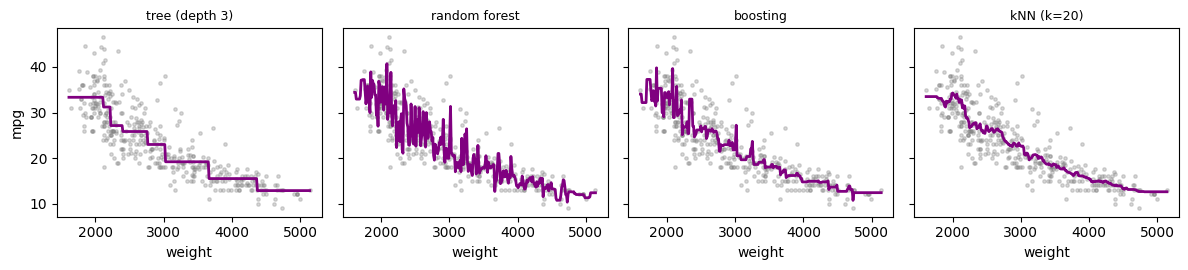

In [7]:
x1 = cars[["weight"]].values
grid = np.linspace(x1.min(), x1.max(), 300).reshape(-1, 1)
models = {
    "tree (depth 3)":  DecisionTreeRegressor(max_depth=3, random_state=0),
    "random forest":   RandomForestRegressor(n_estimators=200, random_state=0),
    "boosting":        GradientBoostingRegressor(n_estimators=200, max_depth=2, random_state=0),
    "kNN (k=20)":      KNeighborsRegressor(n_neighbors=20),
}
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    m.fit(x1, y)
    ax.scatter(x1, y, s=6, color="grey", alpha=0.3)
    ax.plot(grid, m.predict(grid), color="purple", lw=2)
    ax.set_title(name, fontsize=9); ax.set_xlabel("weight")
axes[0].set_ylabel("mpg")
plt.tight_layout(); plt.show()

## 7. Lasso: a shortlist out of many columns



In [8]:
Xs = StandardScaler().fit_transform(cars[PREDS])
las = LassoCV(cv=5, random_state=0).fit(Xs, y)
kept = pd.Series(las.coef_, index=PREDS)
print(f"penalty chosen by cross-validation: {las.alpha_:.4f}\n")
print(kept.round(3).to_string())
print("\nsurvivors:", [p for p, c in kept.items() if abs(c) > 1e-8])

penalty chosen by cross-validation: 0.0858

weight         -5.372
displacement   -0.000
horsepower     -0.000
acceleration    0.108
model_year      2.689
cylinder       -0.170

survivors: ['weight', 'horsepower', 'acceleration', 'model_year', 'cylinder']


Those coefficients were shrunk on purpose, so read the survivors as a shortlist and not as effects.

## 8. Comparing two models: the measure

Same rows, same measure, scored on data neither model was fitted to.

In [9]:
folds = KFold(5, shuffle=True, random_state=0)
cands = {
    "linear regression": LinearRegression(),
    "tree, depth 4":     DecisionTreeRegressor(max_depth=4, random_state=0),
    "tree, depth 10":    DecisionTreeRegressor(max_depth=10, random_state=0),
    "random forest":     RandomForestRegressor(n_estimators=300, random_state=0),
}
for name, m in cands.items():
    fit = m.fit(X, y)
    train_mse = np.mean((fit.predict(X) - y) ** 2)
    s = -cross_val_score(m, X, y, cv=folds, scoring="neg_mean_squared_error")
    print(f"  {name:<20} training MSE {train_mse:6.2f}   CV MSE {s.mean():6.2f} "
          f"(sd {s.std(ddof=1):4.2f})   RMSE {np.sqrt(s.mean()):5.2f} mpg")

  linear regression    training MSE  11.59   CV MSE  12.23 (sd 1.92)   RMSE  3.50 mpg
  tree, depth 4        training MSE   6.74   CV MSE  11.63 (sd 2.44)   RMSE  3.41 mpg
  tree, depth 10       training MSE   0.44   CV MSE  13.19 (sd 3.65)   RMSE  3.63 mpg


  random forest        training MSE   1.02   CV MSE   7.44 (sd 1.71)   RMSE  2.73 mpg


Read the two columns against each other. The depth-10 tree wins on training error and loses on the honest one.

## 9. The other way to compare: AIC

Only for probability models, and only on identical rows.

In [10]:
for f in ["mpg ~ weight", "mpg ~ weight + horsepower",
          "mpg ~ weight + horsepower + model_year"]:
    m = smf.ols(f, data=cars).fit()
    k = int(m.df_model) + 1
    print(f"  {f:<42} k={k}  logL={m.llf:8.1f}  AIC={m.aic:8.1f}  BIC={m.bic:8.1f}")
print("\ncheck the arithmetic:  2k - 2*logL =",
      round(2 * 4 - 2 * smf.ols('mpg ~ weight + horsepower + model_year', data=cars).fit().llf, 1))

  mpg ~ weight                               k=2  logL= -1130.0  AIC=  2263.9  BIC=  2271.9
  mpg ~ weight + horsepower                  k=3  logL= -1121.0  AIC=  2248.0  BIC=  2259.9
  mpg ~ weight + horsepower + model_year     k=4  logL= -1037.4  AIC=  2082.8  BIC=  2098.7

check the arithmetic:  2k - 2*logL = 2082.8


## 10. The five steps, on one regression tree

Fit, tune, predict, put a range on it, and compare. Step 2 is set aside here: choosing a hyperparameter honestly is Unit 4.

In [11]:
# 1. fit
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=1)

# 2. tune: depth is a choice, not something fitting discovers.
#    Choosing it well is Unit 4. Here we simply take 4.
DEPTH = 4
tree = DecisionTreeRegressor(max_depth=DEPTH, random_state=0).fit(Xtr, ytr)
print(f"  depth chosen: {DEPTH}  (how to choose it honestly is Unit 4)")

# 3. predict one held-out car
one = Xte.iloc[[0]]
pred = tree.predict(one)[0]

# 4. a range, from errors on cars it never saw
resid = yte - tree.predict(Xte)
lo, hi = np.percentile(resid, [5, 95])
print(f"\n  prediction: {pred:.1f} mpg")
print(f"  90% interval from held-out errors: {pred + lo:.1f} to {pred + hi:.1f}")
print(f"  actual: {yte.iloc[0]:.1f}")

# 5. compare against the obvious alternative
for name, m in [("tree, depth 4", DecisionTreeRegressor(max_depth=4, random_state=0)),
                ("linear", LinearRegression())]:
    s = -cross_val_score(m, X, y, cv=folds, scoring="neg_mean_squared_error")
    print(f"  {name:<16} CV MSE {s.mean():6.2f}")

  depth chosen: 4  (how to choose it honestly is Unit 4)

  prediction: 22.8 mpg
  90% interval from held-out errors: 18.2 to 30.4
  actual: 23.0
  tree, depth 4    CV MSE  11.63
  linear           CV MSE  12.23


## What to take away




1. The type of `y` picks the probability model and cannot rule out a tree.
2. A model that names no distribution has no p-value, no confidence interval and no AIC.
3. Compare candidates on the same rows with the same measure, scored where neither was fitted.
4. AIC needs a likelihood. Cross-validated error works on anything.
5. Every model goes through the same five steps. Only the tools change.
